In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import (DecisionTreeClassifier, plot_tree)
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score)

In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [7]:
data = load_breast_cancer()
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)
y = pd.Series(data.target, name='target')
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
print("X : ", X.shape)
print("Y : ", y.shape)

X :  (569, 30)
Y :  (569,)


In [14]:
print("X Head : \n", X.head())
print("\nTarget Classes : ", data.target_names)

X Head : 
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0

In [16]:
print(X.isnull().sum().sum())

0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [18]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [22]:
# ============================================================
# 16. ACTUAL VS PREDICTED
# ============================================================

comparison = pd.DataFrame({

    "Actual": y_test.values[:10],

    "Predicted": y_pred[:10]

})


print("\nActual vs Predicted:")
print(comparison)


Actual vs Predicted:
   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       1          1
4       0          0
5       1          1
6       1          1
7       0          0
8       0          0
9       0          0


In [24]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy : ", accuracy)
print("Precision : ", precision)
print("Recall : ", recall)
print("F1 Score : ", f1)

cnm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix : ", cnm)

Accuracy :  0.9122807017543859
Precision :  0.9558823529411765
Recall :  0.9027777777777778
F1 Score :  0.9285714285714286

Confusion Matrix :  [[39  3]
 [ 7 65]]


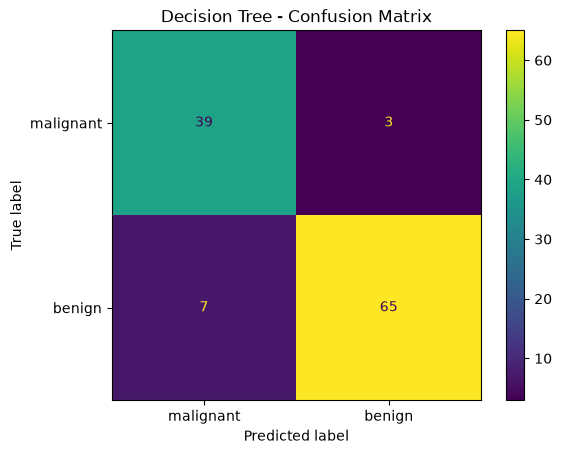

In [25]:
ConfusionMatrixDisplay(
    confusion_matrix=cnm,
    display_labels=data.target_names
).plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [27]:
print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Classification Report
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [29]:
y_probability = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probability)
print("ROC-AUC : ", roc_auc)

ROC-AUC :  0.9156746031746031


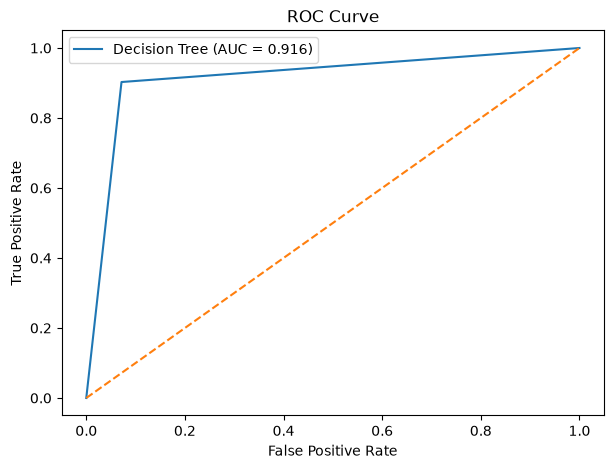

In [30]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc:.3f})")
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
train_accuracy = model.score(
    X_train,
    y_train
)
test_accuracy = model.score(
    X_test,
    y_test
)
print("Training Accuracy : ", train_accuracy)
print("Testing Accuracy : ", test_accuracy)

Training Accuracy :  1.0
Testing Accuracy :  0.9122807017543859


In [32]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
print("\nCross Validation")
print("CV Scores : ", cv_scores)
print("Mean CV Accuracy : ", cv_scores.mean())


Cross Validation
CV Scores :  [0.9122807  0.90350877 0.92982456 0.95614035 0.88495575]
Mean CV Accuracy :  0.9173420276354604


In [33]:
param_grid = {
    "criterion" : ["gini", 'entropy', 'log_loss'],
    "max_depth" : [3, 5, 7, 10, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1
)

In [34]:
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model = grid_search.best_estimator_

print("Best Params : ", best_params)
print("Best CV Accuracy : ", best_score)
print("Best Model : ", best_model)

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best Params :  {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Accuracy :  0.9384615384615385
Best Model :  DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)


In [36]:
y_pred_best = best_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_best)
final_precision = precision_score(y_test, y_pred_best)
final_recall = recall_score(y_test, y_pred_best)
final_f1 = f1_score(y_test, y_pred_best)

print("Final Accuracy : ", final_accuracy)
print("Final Precision : ", final_precision)
print("Final Recall : ", final_recall)
print("F1 Final Score : ", final_f1)

Final Accuracy :  0.9210526315789473
Final Precision :  0.9565217391304348
Final Recall :  0.9166666666666666
F1 Final Score :  0.9361702127659575


In [ ]:
cnm_best = confusion_matrix(y_test, y_pred_best)
print(cnm_best)

[[39  3]
 [ 6 66]]


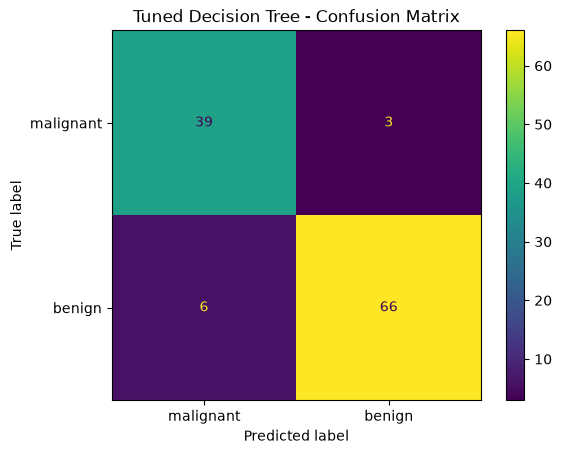

In [39]:
ConfusionMatrixDisplay(
    confusion_matrix=cnm_best,
    display_labels=data.target_names
).plot()
plt.title("Tuned Decision Tree - Confusion Matrix")
plt.show()

In [40]:
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



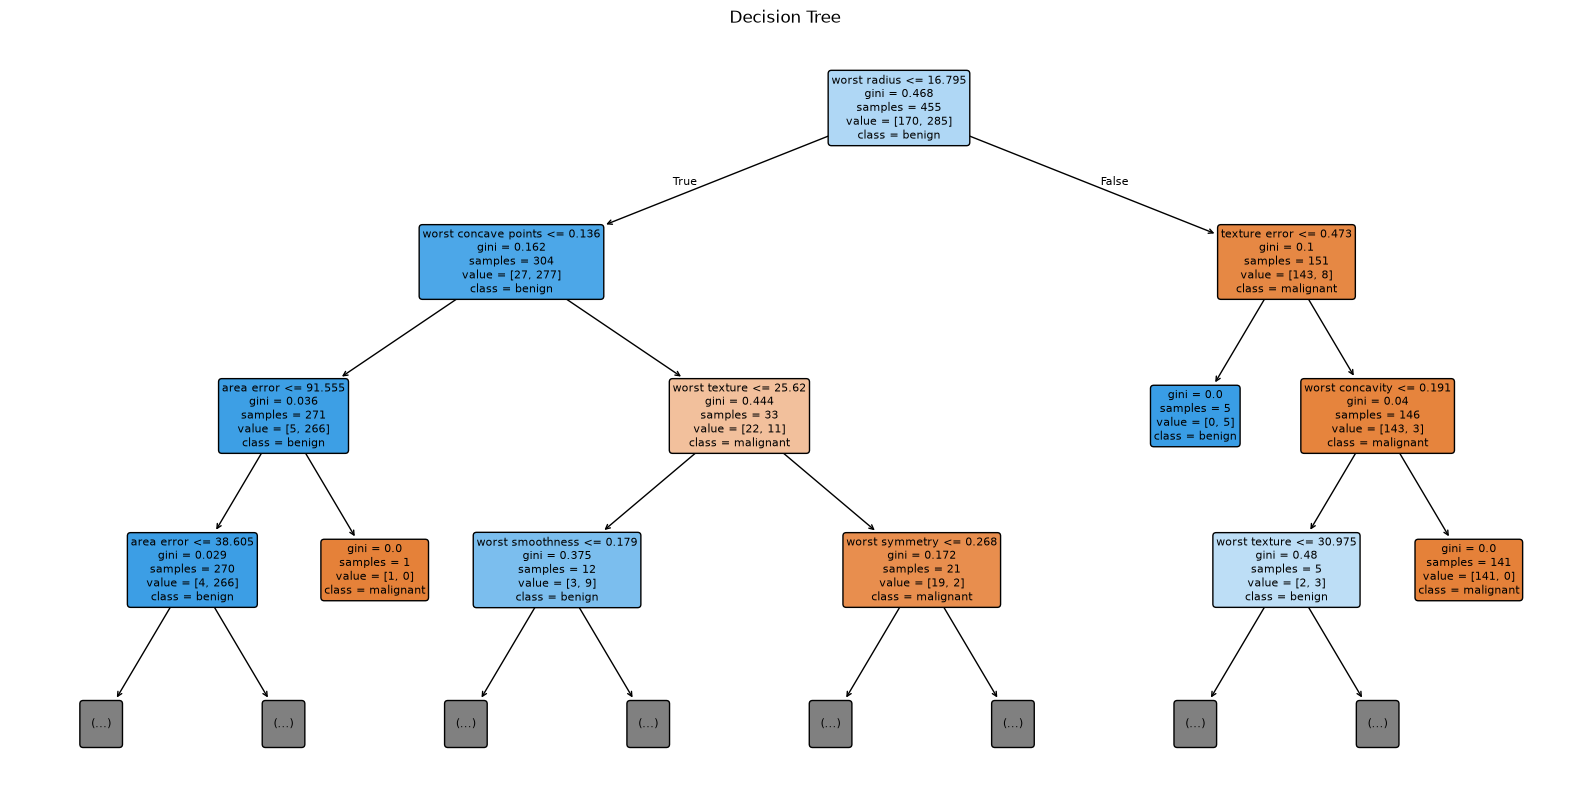

In [41]:
plt.figure(figsize=(20,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    max_depth=3
)
plt.title("Decision Tree")
plt.show()

In [42]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
20          worst radius    0.718940
27  worst concave points    0.119597
11         texture error    0.054255
21         worst texture    0.043286
26       worst concavity    0.016819
24      worst smoothness    0.013062
13            area error    0.012451
28        worst symmetry    0.011058
23            worst area    0.008708
14      smoothness error    0.001824


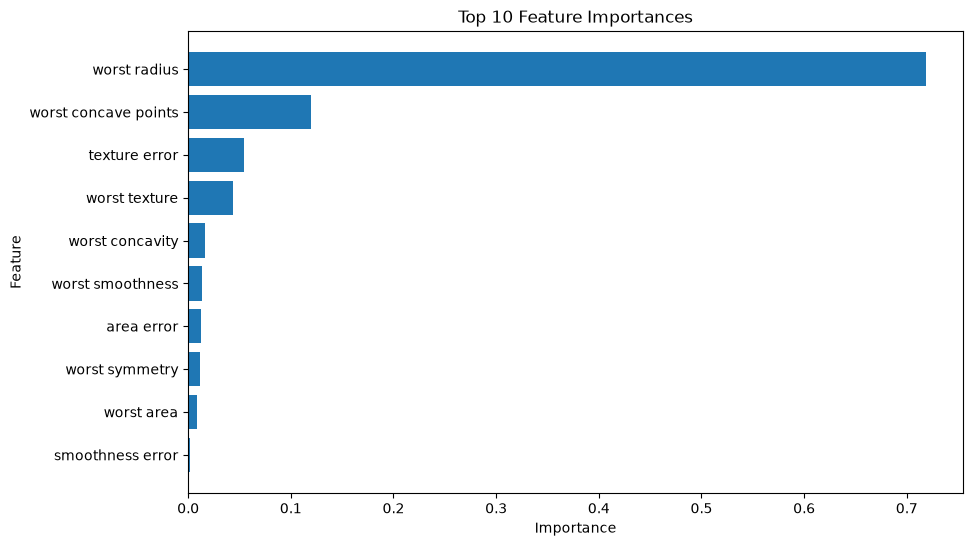

In [44]:
top_features = feature_importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()